# Exon Inclusion Analysis

In [1]:
!pip install ipykernel
!python -m ipykernel install --user --name finalproject --display-name "Python (final project)"

Installed kernelspec finalproject in /home/biouser/.local/share/jupyter/kernels/finalproject


In [2]:
## 0. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from functions import (
    load_type_data,
    compute_spearman_corr,
    spearman_corr_labels,
    preprocess_type,
    load_subtype_data,
    preprocess_subtype,
)

## 1. Load Data
- Load `altExonUsage_devel_type.gz`
- Filter only column with `Neuron` 
- Combine `Exon` and `Gene` to `GE` (`Exon::Gene`)
- Remove rows with missing data `NaN`

In [3]:
type_neurons = load_type_data("../../data/altExonUsage_devel_type.gz")
type_neurons.head(10)

,P14_Hippocampus_ExciteNeuron,P14_Hippocampus_InhibNeuron,P14_VisCortex_ExciteNeuron,P14_VisCortex_InhibNeuron,P21_Hippocampus_ExciteNeuron,P21_Hippocampus_InhibNeuron,P21_VisCortex_ExciteNeuron,P21_VisCortex_InhibNeuron,P28_Hippocampus_ExciteNeuron,P28_Hippocampus_InhibNeuron,P28_VisCortex_ExciteNeuron,P28_VisCortex_InhibNeuron,P56_Hippocampus_ExciteNeuron,P56_Hippocampus_InhibNeuron,P56_VisCortex_ExciteNeuron,P56_VisCortex_InhibNeuron
GE,,,,,,,,,,,,,,,,
chr1_162273620_162273649_-::ENSMUSG00000040265.16,0.032520,0.000000,0.008152,0.000000,0.049351,0.024000,0.000000,0.000000,0.015544,0.007812,0.001163,0.000000,0.015831,0.026316,0.005181,0.001821
chr1_83384894_83384972_-::ENSMUSG00000026163.17,0.608364,0.642140,0.707604,0.657718,0.631307,0.707113,0.767779,0.776471,0.670919,0.666667,0.789824,0.805970,0.641826,0.694915,0.781662,0.712150
chr1_16486020_16486150_-::ENSMUSG00000025920.19,0.204724,0.032967,0.240229,0.097222,0.222116,0.230769,0.275465,0.102564,0.223958,0.000000,0.230177,0.132075,0.218418,0.050633,0.220895,0.145867
chr1_30837105_30837266_-::ENSMUSG00000048874.15,0.159420,0.082569,0.141469,0.195122,0.148862,0.163043,0.153000,0.217391,0.192575,0.172414,0.170354,0.205882,0.128942,0.253333,0.183346,0.246057
chr1_42663556_42663602_-::ENSMUSG00000060424.14,0.313793,0.322222,0.341404,0.342593,0.353125,0.354167,0.423520,0.370968,0.304668,0.275862,0.426385,0.526316,0.388466,0.400000,0.439563,0.340741
chr1_84795690_84795815_-::ENSMUSG00000026219.14,0.288591,0.472222,0.331536,0.444444,0.320594,0.327273,0.362587,0.466667,0.322695,0.523810,0.380399,0.363636,0.278626,0.428571,0.391031,0.355769
chr1_121312201_121312325_-::ENSMUSG00000003721.14,0.891176,0.910448,0.803970,0.846154,0.797701,0.858974,0.817054,0.812500,0.903448,0.833333,0.898990,0.940000,0.806051,0.921569,0.849558,0.894118
chr1_121307140_121307306_-::ENSMUSG00000003721.14,0.896359,0.914286,0.814554,0.857143,0.800680,0.860759,0.824047,0.823529,0.906822,0.846154,0.902439,0.941176,0.812874,0.927273,0.850332,0.892000
chr1_133004654_133004721_-::ENSMUSG00000054387.13,0.994475,0.804348,0.975676,0.857143,0.845659,0.406977,0.786689,0.394737,0.938511,0.842105,0.965812,0.851852,0.964720,0.722222,0.947581,0.783784


## 2. Performn Pairwise Correlation

- Compute Spearman correlation matrix
- Rename indices "Hippocampus" -> "HIPP" & "VisCortex" -> "VIS" 

In [4]:
CN = compute_spearman_corr(type_neurons)
CN = preprocess_type(CN)
CN

,P14_HIPP_Excite,P14_HIPP_Inhib,P14_VIS_Excite,P14_VIS_Inhib,P21_HIPP_Excite,P21_HIPP_Inhib,P21_VIS_Excite,P21_VIS_Inhib,P28_HIPP_Excite,P28_HIPP_Inhib,P28_VIS_Excite,P28_VIS_Inhib,P56_HIPP_Excite,P56_HIPP_Inhib,P56_VIS_Excite,P56_VIS_Inhib
P14_HIPP_Excite,1.000000,0.884217,0.962237,0.899971,0.971003,0.868121,0.947010,0.860983,0.949210,0.850278,0.943170,0.880083,0.961826,0.902950,0.934050,0.886542
P14_HIPP_Inhib,0.884217,1.000000,0.878134,0.910373,0.870207,0.916648,0.853516,0.846149,0.863946,0.909185,0.855788,0.883274,0.869281,0.925440,0.854794,0.904063
P14_VIS_Excite,0.962237,0.878134,1.000000,0.925685,0.954540,0.876602,0.964306,0.877206,0.928853,0.850946,0.958362,0.900242,0.935769,0.900521,0.946463,0.906316
P14_VIS_Inhib,0.899971,0.910373,0.925685,1.000000,0.890136,0.889708,0.888126,0.880438,0.871564,0.882559,0.886951,0.917194,0.883123,0.912734,0.880189,0.913409
P21_HIPP_Excite,0.971003,0.870207,0.954540,0.890136,1.000000,0.886830,0.973686,0.887591,0.968928,0.860166,0.964302,0.892825,0.981593,0.917818,0.965583,0.909689
P21_HIPP_Inhib,0.868121,0.916648,0.876602,0.889708,0.886830,1.000000,0.892030,0.904615,0.879264,0.911842,0.881864,0.912125,0.874085,0.931539,0.885403,0.941667
P21_VIS_Excite,0.947010,0.853516,0.964306,0.888126,0.973686,0.892030,1.000000,0.912379,0.950948,0.858103,0.980269,0.900454,0.952490,0.905970,0.983004,0.925432
P21_VIS_Inhib,0.860983,0.846149,0.877206,0.880438,0.887591,0.904615,0.912379,1.000000,0.883744,0.859579,0.891405,0.899474,0.874334,0.891868,0.899297,0.925791
P28_HIPP_Excite,0.949210,0.863946,0.928853,0.871564,0.968928,0.879264,0.950948,0.883744,1.000000,0.874911,0.966287,0.884917,0.970060,0.912727,0.951848,0.906948
P28_HIPP_Inhib,0.850278,0.909185,0.850946,0.882559,0.860166,0.911842,0.858103,0.859579,0.874911,1.000000,0.863372,0.891848,0.856964,0.916498,0.858614,0.912753


## 3. Heat Map of Pairwise Correlation for Excitatory and Inhibitory Types

- Extract metadata from the table's index to create labels for the heat map
    - `Age`, `Region`, `Type` 
- Create colour palettes for each label
- Create a cluster map
    - Dendrogram of excitatory type & inhitory type
    - Heat map of Spearman pairwise correlations of exon inclusion for each cell type 

In [5]:
# Create labels for the heatmap
cnn = spearman_corr_labels(CN)
cnn

,CT,Age,Region,Type
0,P14_HIPP_Excite,P14,HIPP,Excite
1,P14_HIPP_Inhib,P14,HIPP,Inhib
2,P14_VIS_Excite,P14,VIS,Excite
3,P14_VIS_Inhib,P14,VIS,Inhib
4,P21_HIPP_Excite,P21,HIPP,Excite
5,P21_HIPP_Inhib,P21,HIPP,Inhib
6,P21_VIS_Excite,P21,VIS,Excite
7,P21_VIS_Inhib,P21,VIS,Inhib
8,P28_HIPP_Excite,P28,HIPP,Excite
9,P28_HIPP_Inhib,P28,HIPP,Inhib


In [6]:
## Define colour palettes

# Ages 
ages = ["P14", "P21", "P28", "P56"]
ages_colour = ["#ae3b24", "#c8812a", "#56632c" ,"#f68d62"]
ages_palette = dict(zip(ages, ages_colour))

# Regions
regions = ["VIS", "HIPP"]
regions_colour = ["#ddbbc6", "#fdc681"]
regions_palette = dict(zip(regions, regions_colour))

# Cell types
cts = ["Excite", "Inhib", "Inh_wCR"]
cts_colour = ["#ffcc5c", "#65c3ba", "#82d188"]
cts_palette = dict(zip(cts, cts_colour))

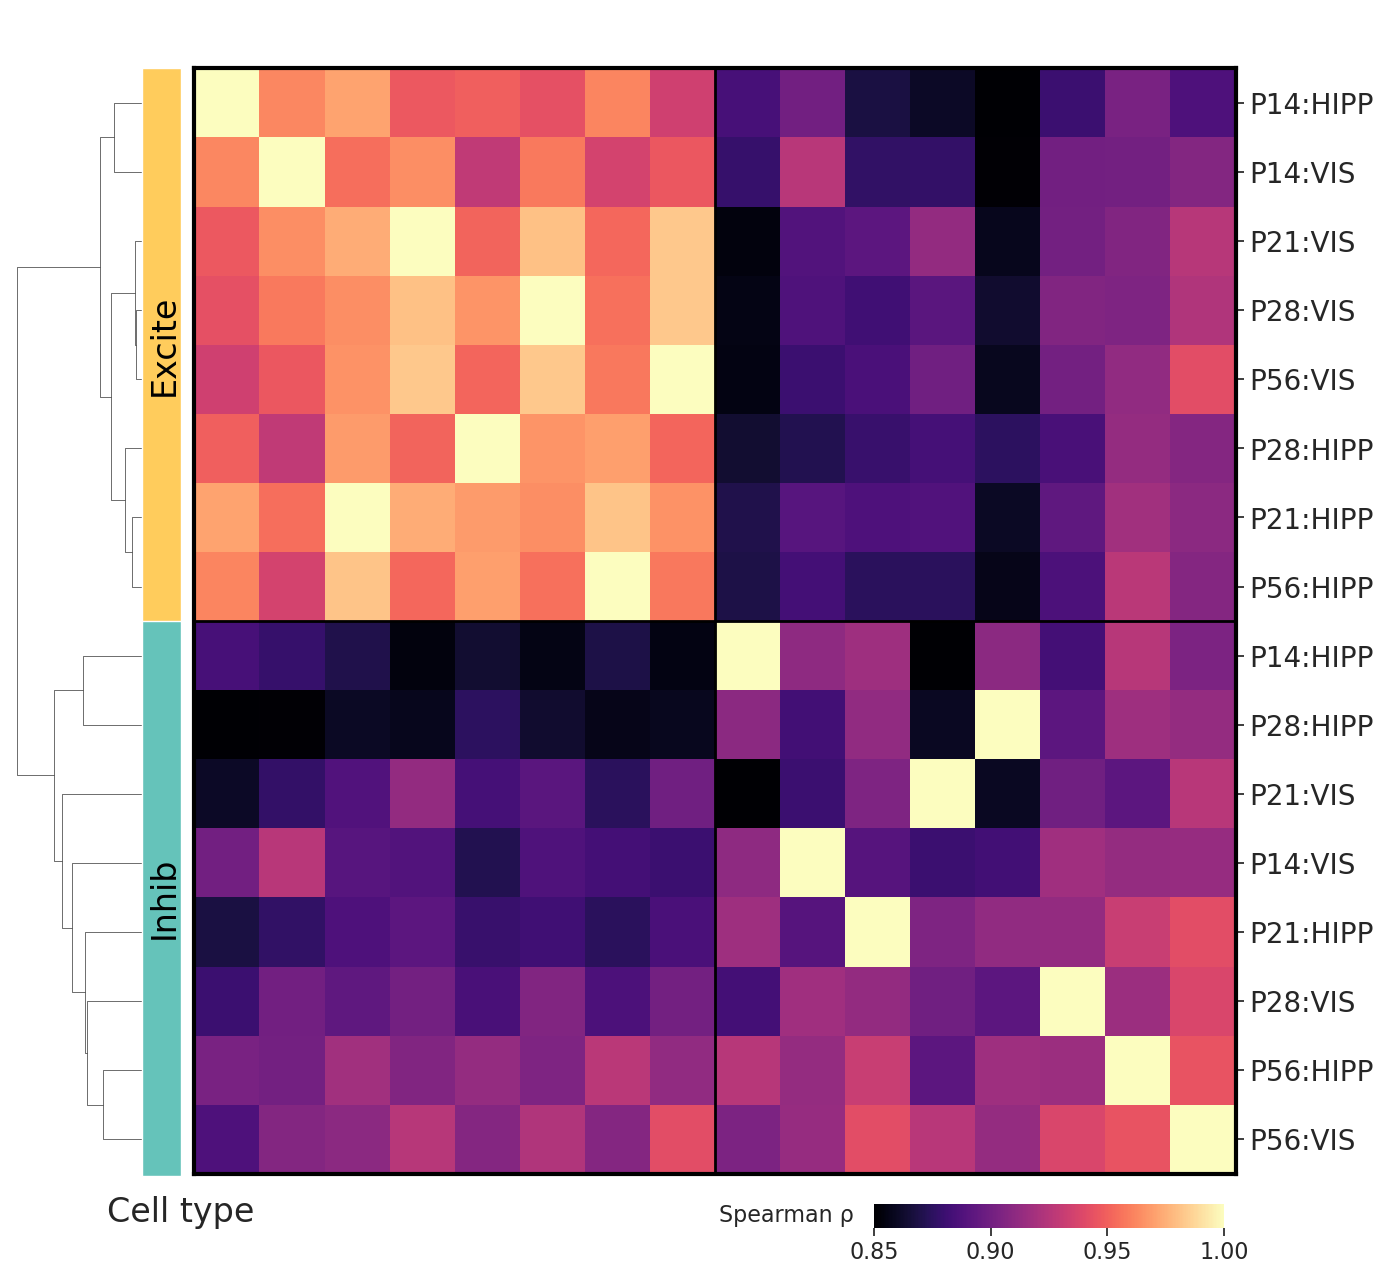

In [7]:
from scipy.spatial.distance import squareform
import scipy.cluster.hierarchy as sch
from matplotlib.patches import Rectangle

# Prepare row order
excite = cnn[cnn["Type"] == "Excite"]["CT"].tolist()
inhib  = cnn[cnn["Type"] == "Inhib"]["CT"].tolist()

row_order = excite + inhib
CN2 = CN.loc[row_order, row_order]

np.fill_diagonal(CN2.values, 1.0)

# Create masked correlation 
CN_masked = CN2.copy()

# Set cross-type correlations LOW
for r in excite:
    for c in inhib:
        CN_masked.loc[r, c] = 0
        CN_masked.loc[c, r] = 0

# Force symmetry and diagonal 
CN_masked = (CN_masked + CN_masked.T) / 2
np.fill_diagonal(CN_masked.values, 1)

# Convert correlation → distance
dist = 1 - CN_masked

# Linkage 2 clusters
condensed = squareform(dist.values, checks=True)
Z = sch.linkage(condensed, method="complete", optimal_ordering=True)

# Side colour labels
row_colours = pd.Series(row_order).map(
    lambda ct: cts_palette["Excite"] if ct in excite else cts_palette["Inhib"]
)

# Clustermap 
sns.set_theme(style="white")

g = sns.clustermap(
    CN2,
    figsize=(14, 12),
    row_colors=row_colours,
    col_cluster=False,
    cmap="magma",
    vmin=0.85,
    vmax=1.0,
    dendrogram_ratio=(0.12, 0.05),
    cbar_kws= {"orientation": "horizontal", "ticks" : [0.85, 0.9, 0.95, 1.0]},
    cbar_pos=(0.63, -0.03, 0.25, 0.02),
    xticklabels=False,
    yticklabels=True,
)

# Rename y-tick labels -> Age:Region
ylabels = []
for ct in g.data2d.index:
    row = cnn.loc[cnn["CT"] == ct].iloc[0]
    label = f"{row['Age']}:{row['Region']}"
    ylabels.append(label)

g.ax_heatmap.set_yticklabels(ylabels, fontsize=20)

# Add border
for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(3)
    spine.set_color("black")

# Add cluster border line
n_excite = len(excite)
g.ax_heatmap.axhline(n_excite, color="black", linewidth=2)
g.ax_heatmap.axvline(n_excite, color="black", linewidth=2)

# Add cluster labels
ax = g.ax_heatmap

# Excite
ax.text(-0.47, n_excite/2, "Excite",
        rotation=90,
        va="center",
        ha="center",
        fontsize=24,
        color="black",
)

# Inhib
ax.text(-0.47, n_excite + (len(inhib)/2), "Inhib",
        rotation=90,
        va="center",
        ha="center",
        fontsize=24,
        color="black",
)

# Add rectangular colour blocks for cluster labels
ax.add_patch(Rectangle(
    (-0.8, 0),
    0.6,
    n_excite + 0.03,
    transform=ax.transData,
    facecolor=cts_palette["Excite"],
    clip_on=False
))

ax.add_patch(Rectangle(
    (-0.8, n_excite),
    0.6,
    len(inhib) + 0.03,
    transform=ax.transData,
    facecolor=cts_palette["Inhib"],
    clip_on=False
))

g.ax_heatmap.set_ylabel(None)
g.ax_heatmap.text(
    -1.35, 16.8,
    "Cell type",
    va="bottom",
    ha="left",
    fontsize=24,
)

# Add colour bar
cbar = g.cax
cbar.set_ylabel(None)
cbar.text(
    -0.25, 0.03,               
    "Spearman ρ",             
    va="bottom",
    ha="center",
    fontsize=16,
    transform=cbar.transAxes,
)

# Increase tick label font size
for tick in cbar.get_xticklabels():
    tick.set_fontsize(16)

plt.savefig("../plots/heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Box Plot of Pairwise Correlation for Excitatory and Inhibitory Types

- Load `altExonUsage_devel_subtype.gz`
- Filter only column with `Inh`, `Excite`, `Granule`, and `NIPC`
- Combine `Exon` and `Gene` to `GE` (`Exon::Gene`)
- Remove rows with missing data `NaN`
- Separate neuronal cell types into `Excite`, `Inhib`, and `Inh` 

In [8]:
subtype_alt = load_subtype_data("../../data/altExonUsage_devel_subtype.gz")
subtype_alt.shape

(0, 55)

In [9]:
subtype_alt.head(20)

,P14_Hippocampus_ExciteCA,P14_Hippocampus_ExciteDG,P14_Hippocampus_InhCajalRetzius,P14_Hippocampus_InhibNeuron,P14_Hippocampus_GranuleNB,P14_Hippocampus_NIPCs,P14_VisCortex_ExciteL23,P14_VisCortex_ExciteL4,P14_VisCortex_ExciteL5,P14_VisCortex_ExciteL6,...,P56_Hippocampus_GranuleNB,P56_Hippocampus_NIPCs,P56_VisCortex_ExciteL23,P56_VisCortex_ExciteL4,P56_VisCortex_ExciteL5,P56_VisCortex_ExciteL6,P56_VisCortex_ExciteNP,P56_VisCortex_InhibNeuron,P56_VisCortex_NIPCs,P56_VisCortex_InhCajalRetzius
GE,,,,,,,,,,,,,,,,,,,,,


In [10]:
subtype_alt = preprocess_subtype(subtype_alt)
CN_subtype = compute_spearman_corr(subtype_alt)
CN_subtype

""


In [11]:
# Excite correlation
tmp_excite = CN.filter(like="Excite", axis=1)           
tmp_excite = tmp_excite.loc[[i for i in CN.index if "Excite" in i]]  
CE = tmp_excite.values[np.triu_indices_from(tmp_excite, k=1)]         #

# Inhib correlations (upper triangle only)
tmp_inhib = CN.filter(like="Inhib", axis=1)
tmp_inhib = tmp_inhib.loc[[i for i in CN.index if "Inhib" in i]]
CI = tmp_inhib.values[np.triu_indices_from(tmp_inhib, k=1)]

df = pd.DataFrame({
    "CorValue": np.concatenate([CE, CI]),
    "Type": ["Excite"]*len(CE) + ["Inhib"]*len(CI)
})

# -----------------------------
# Step 3: Read in subtype PSI values
# -----------------------------
subtype_alt = load_subtype_neurons("../../data/altExonUsage_devel_subtype.gz")

# Select only neuron-related columns and combine Exon and Gene as row index
cols_to_keep = [c for c in subtype_alt.columns if any(x in c for x in ["Excite","Inh","Granule","NIPC"])]
subtype_neurons = subtype_alt[["Exon","Gene"] + cols_to_keep].copy()
subtype_neurons.index = subtype_neurons["Exon"] + "::" + subtype_neurons["Gene"]
subtype_neurons = subtype_neurons.drop(columns=["Exon","Gene"])

# -----------------------------
# Step 4: Filter based on missing data thresholds
# -----------------------------
threshold = 0.95
subtype_neurons2 = subtype_neurons.loc[:, subtype_neurons.isna().mean() < threshold]
subtype_neurons2 = subtype_neurons2.loc[subtype_neurons2.isna().mean(axis=1) <= threshold, :]

# -----------------------------
# Step 5: Compute Spearman correlations
# -----------------------------
C_st_N = subtype_neurons2.corr(method="spearman")

# -----------------------------
# Step 6: Separate Excite, Inhib, and Inh with Cajal Retzius (CR)
# -----------------------------
# Separate into Excite, Inh, Inh_wCR
tmp_excite = C_st_N.filter(like="Excite").loc[C_st_N.index.str.contains("Excite")]
CE = tmp_excite.values[np.triu_indices_from(tmp_excite, k=1)]

tmp_inhib_all = C_st_N.filter(like="Inhib").loc[C_st_N.index.str.contains("Inhib")]
CI = tmp_inhib_all.values[np.triu_indices_from(tmp_inhib_all, k=1)]

tmp_inh_wcr = C_st_N.filter(like="Inh").loc[C_st_N.index.str.contains("Inh")]
CR = tmp_inh_wcr.values[np.triu_indices_from(tmp_inh_wcr, k=1)]

# Combine into a DataFrame
df = pd.DataFrame({
    "CorValue": np.concatenate([CE, CR, CI]),
    "Type": ["Excite"]*len(CE) + ["Inh_wCR"]*len(CR) + ["Inhib"]*len(CI)
})

# Ensure the order
df["Type"] = pd.Categorical(df["Type"], categories=["Excite", "Inh_wCR", "Inhib"], ordered=True)

# -----------------------------
# Plot horizontal boxplot
# -----------------------------
plt.figure(figsize=(6,6))
sns.boxplot(
    data=df,
    x="Type",
    y="CorValue",   
    palette=["#ffcc5c","#82d188","#65c3ba"],
    width=0.6
)
plt.ylabel("Spearman ρ")
plt.xlabel("Cell type")
plt.title("b, Box plot of pairwise correlations of Ψ values by cell type", fontsize=12)
sns.despine(trim=True)
plt.savefig("../plots/boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'load_subtype_neurons' is not defined

In [ ]:
row_order

['P14_HIPP_Excite',
 'P14_VIS_Excite',
 'P21_HIPP_Excite',
 'P21_VIS_Excite',
 'P28_HIPP_Excite',
 'P28_VIS_Excite',
 'P56_HIPP_Excite',
 'P56_VIS_Excite',
 'P14_HIPP_Inhib',
 'P14_VIS_Inhib',
 'P21_HIPP_Inhib',
 'P21_VIS_Inhib',
 'P28_HIPP_Inhib',
 'P28_VIS_Inhib',
 'P56_HIPP_Inhib',
 'P56_VIS_Inhib']

In [ ]:
excite_order, Z_excite

NameError: name 'excite_order' is not defined

In [ ]:
inhib_order, Z_inhib

(['P21_VIS_Inhib',
  'P14_VIS_Inhib',
  'P28_VIS_Inhib',
  'P14_HIPP_Inhib',
  'P28_HIPP_Inhib',
  'P21_HIPP_Inhib',
  'P56_HIPP_Inhib',
  'P56_VIS_Inhib'],
 array([[ 6.        ,  7.        ,  0.05520426,  2.        ],
        [ 2.        ,  8.        ,  0.06846081,  3.        ],
        [ 1.        ,  5.        ,  0.08280602,  2.        ],
        [ 4.        ,  9.        ,  0.08815829,  4.        ],
        [ 0.        , 11.        ,  0.09593718,  5.        ],
        [10.        , 12.        ,  0.11744125,  7.        ],
        [ 3.        , 13.        ,  0.1538508 ,  8.        ]]))